# AI Impact on Jobs 2030
**Author:** Memuletiwon Oluwafemi  
**Tools:** Python · pandas · matplotlib · seaborn  

## Project Overview
An end-to-end data analysis examining how AI is reshaping the global 
workforce by 2030 — covering 3,000 employee records across 10 industries 
and 10 countries.

## Key Questions
- Which industries and job titles carry the highest AI replacement risk?
- Which countries have the most exposed workforce?
- What skills are most in demand by 2030?
- How is AI affecting hiring trends?
- Are high-risk workers more likely to need upskilling?

## 1. Data Loading & Exploration

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [172]:
jobs = pd.read_csv("AI_Impact_on_Jobs_2030.csv")
jobs.head()

,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,AIJ-100000,Data Engineer,Healthcare,Japan,PhD,1,0.25,0.78,Yes,207392,"Python, Communication, Deep Learning",Low,3,37,Enterprise,High,2.08,Yes,3.86,Growing
1,AIJ-100001,Healthcare Analyst,Retail,UK,Bachelor,24,0.73,0.33,No,140785,"Deep Learning, Azure, Communication, TensorFlo...",Low,-5,42,Startup,Moderate,4.54,No,4.23,Growing
2,AIJ-100002,HR Specialist,Education,Canada,High School,21,0.80,0.69,Yes,124800,"Kubernetes, Cloud Computing, TensorFlow, SQL, ...",Medium,-5,57,Startup,Low,3.14,No,3.54,Stable
3,AIJ-100003,Cybersecurity Analyst,Government,UK,Bachelor,5,0.29,0.94,No,199878,"Excel, Kubernetes, Prompt Engineering, Leadership",Medium,7,59,Enterprise,High,3.67,No,4.37,Declining
4,AIJ-100004,Healthcare Analyst,Education,UAE,PhD,20,0.11,0.92,No,178682,"SQL, Leadership, TensorFlow, Cybersecurity",Low,6,34,Startup,High,3.68,No,3.99,Stable


In [24]:
jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Employee_ID              3000 non-null   object 
 1   Job_Title                3000 non-null   object 
 2   Industry                 3000 non-null   object 
 3   Country                  3000 non-null   object 
 4   Education_Level          3000 non-null   object 
 5   Years_Experience         3000 non-null   int64  
 6   AI_Replacement_Risk      3000 non-null   float64
 7   Future_Demand_Score      3000 non-null   float64
 8   Remote_Work_Possibility  3000 non-null   object 
 9   Average_Salary_USD       3000 non-null   int64  
 10  Required_Skills          3000 non-null   object 
 11  Automation_Level         3000 non-null   object 
 12  Job_Growth_2030          3000 non-null   int64  
 13  Work_Hours_Per_Week      3000 non-null   int64  
 14  Company_Size            

In [25]:
jobs.describe()

,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Average_Salary_USD,Job_Growth_2030,Work_Hours_Per_Week,Performance_Score,Job_Satisfaction
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,12.383000,0.502910,0.601203,126641.746667,17.238333,44.773333,3.514643,3.026167
std,7.528958,0.261293,0.226674,55405.053057,16.230322,8.926469,0.873375,1.146361
min,0.000000,0.050000,0.200000,30221.000000,-10.000000,30.000000,2.000000,1.000000
25%,6.000000,0.280000,0.420000,77262.000000,3.000000,37.000000,2.760000,2.060000
50%,12.000000,0.500000,0.600000,127660.500000,17.000000,45.000000,3.540000,3.025000
75%,19.000000,0.730000,0.800000,174811.750000,31.000000,52.000000,4.270000,4.010000
max,25.000000,0.950000,0.990000,219998.000000,45.000000,60.000000,5.000000,5.000000


In [26]:
jobs[jobs.isnull().any(axis=1)]

,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026


In [27]:
jobs.shape

(3000, 20)

## 2. Data Preprocessing

In [37]:
jobs["Risk_Tier"] = pd.cut(
    jobs["AI_Replacement_Risk"],
    bins=[0, 0.40, 0.70, 1.0],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

jobs["Risk_Tier"].value_counts()

Risk_Tier
Low Risk       1170
Medium Risk     975
High Risk       855
Name: count, dtype: int64

In [35]:
jobs["Experience_Band"] = pd.cut(
    jobs["Years_Experience"],
    bins=[0, 5, 15, 25],
    labels=["Junior (0–5 yrs)", "Mid-Level (6–15 yrs)", "Senior (16–25 yrs)"],
    include_lowest = True
)

jobs["Experience_Band"].value_counts()

Experience_Band
Mid-Level (6–15 yrs)    1164
Senior (16–25 yrs)      1132
Junior (0–5 yrs)         704
Name: count, dtype: int64

In [38]:
jobs.to_csv("cleaned_data.csv", index=False)
print("Done!")

Done!


In [39]:
df = pd.read_csv("cleaned_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Employee_ID              3000 non-null   object 
 1   Job_Title                3000 non-null   object 
 2   Industry                 3000 non-null   object 
 3   Country                  3000 non-null   object 
 4   Education_Level          3000 non-null   object 
 5   Years_Experience         3000 non-null   int64  
 6   AI_Replacement_Risk      3000 non-null   float64
 7   Future_Demand_Score      3000 non-null   float64
 8   Remote_Work_Possibility  3000 non-null   object 
 9   Average_Salary_USD       3000 non-null   int64  
 10  Required_Skills          3000 non-null   object 
 11  Automation_Level         3000 non-null   object 
 12  Job_Growth_2030          3000 non-null   int64  
 13  Work_Hours_Per_Week      3000 non-null   int64  
 14  Company_Size            

In [40]:
df[df.isnull().any(axis=1)]

,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,...,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026,Experience_Band,Risk_Tier


## 3. Exploratory Data Analysis (EDA)

In [78]:
industry_risk = (df.groupby("Industry")["AI_Replacement_Risk"]
                .mean()
                .sort_values(ascending=True).reset_index()
                )

industry_risk

,Industry,AI_Replacement_Risk
0,Healthcare,0.475238
1,Media,0.489547
2,Transportation,0.493754
3,Manufacturing,0.495875
4,Retail,0.496316
5,Education,0.496933
6,Energy,0.499164
7,Technology,0.517423
8,Government,0.528793
9,Finance,0.530484


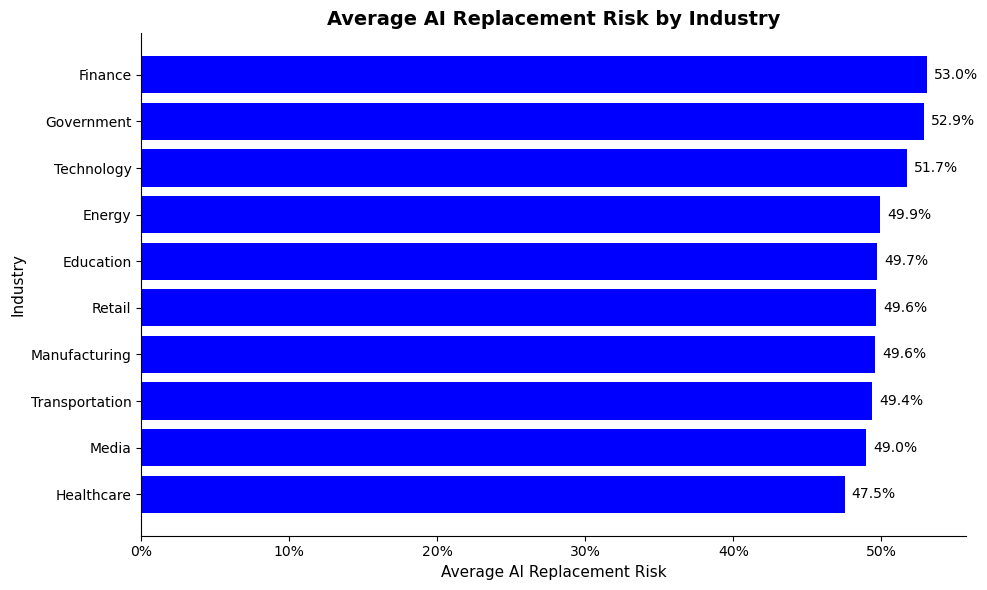

In [178]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(industry_risk.Industry, industry_risk.AI_Replacement_Risk, color="b")
ax.bar_label(bars, fmt=lambda x: f"{x * 100:.1f}%", padding=5, fontsize=10)
ax.set_title("Average AI Replacement Risk by Industry", fontsize=14, fontweight="bold")
ax.set_xlabel("Average AI Replacement Risk", fontsize=11)
ax.set_ylabel("Industry", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x * 100:.0f}%"))
plt.tight_layout()
plt.savefig("visuals/chart1_industry_risk.png", dpi=150, bbox_inches="tight")
plt.show()

#### Finance is the highest-risk industry at 53.0%, while Healthcare 
is the most insulated at 47.5%. The narrow 5.5% spread across all 
10 industries suggests AI disruption risk is broadly distributed 
rather than concentrated in any single sector.

In [76]:
job_risk = (df.groupby("Job_Title")["AI_Replacement_Risk"]
              .mean()
              .sort_values(ascending=True).reset_index())
job_risk

,Job_Title,AI_Replacement_Risk
0,UX Designer,0.460443
1,Data Scientist,0.470263
2,Machine Learning Engineer,0.472229
3,Business Analyst,0.473475
4,AI Engineer,0.476452
5,Financial Analyst,0.485315
6,Product Manager,0.486433
7,Digital Marketer,0.489403
8,HR Specialist,0.492209
9,Software Developer,0.496951


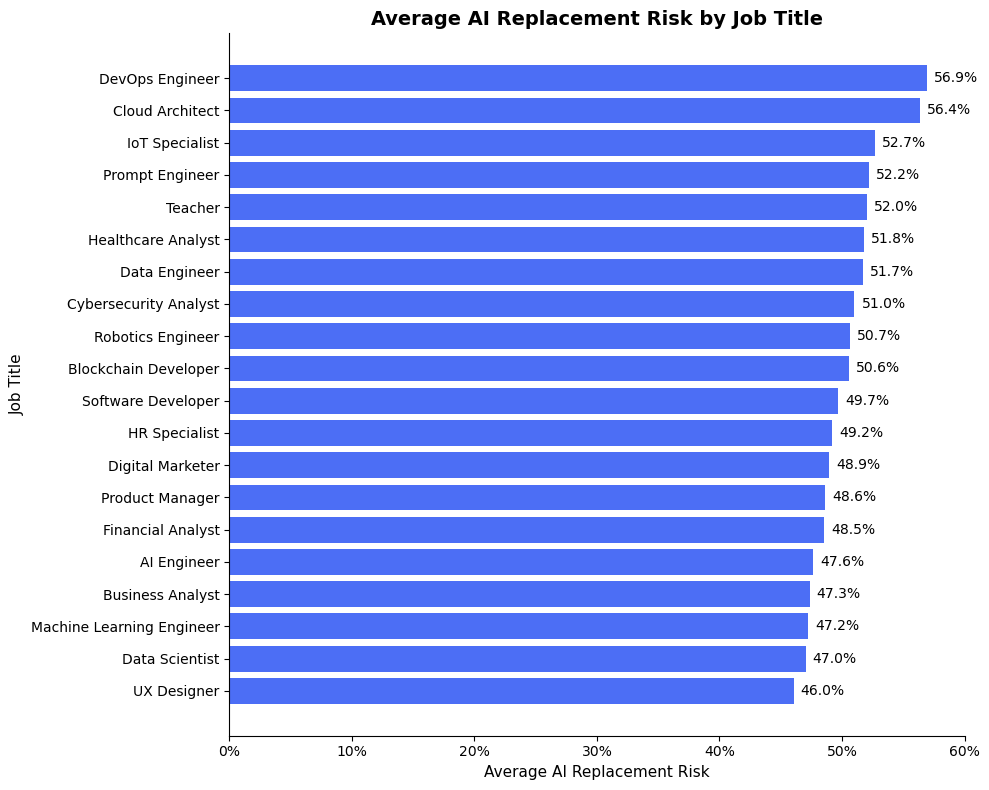

In [179]:
fig, ax = plt.subplots(figsize=(10,8))
bars= ax.barh(job_risk.Job_Title, job_risk.AI_Replacement_Risk, color="#4C6EF5", edgecolor="none")
ax.bar_label(bars, fmt=lambda x: f"{x * 100:.1f}%", padding=5, fontsize=10)


ax.set_title("Average AI Replacement Risk by Job Title", fontsize=14, fontweight="bold")
ax.set_xlabel("Average AI Replacement Risk", fontsize=11)
ax.set_ylabel("Job Title", fontsize=11)


ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x * 100:.0f}%"))

ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, 0.60)

plt.tight_layout()

plt.savefig("visuals/chart2_jobtitle_risk.png", dpi=150, bbox_inches="tight")
plt.show()

#### Job title risk follows a similar pattern — the spread across 
all 20 job titles is narrow, suggesting no single role is dramatically 
more exposed than others. However DevOps Engineers and Cloud Architects 
appear at the top while UX Designers and Data Scientists show the 
lowest risk.

In [119]:
print(df["Required_Skills"].head(10))

0                 Python, Communication, Deep Learning
1    Deep Learning, Azure, Communication, TensorFlo...
2    Kubernetes, Cloud Computing, TensorFlow, SQL, ...
3    Excel, Kubernetes, Prompt Engineering, Leadership
4           SQL, Leadership, TensorFlow, Cybersecurity
5    Excel, Deep Learning, Cybersecurity, Communica...
6    Leadership, Cloud Computing, Project Managemen...
7                              Leadership, AWS, Python
8    Docker, PyTorch, Prompt Engineering, Azure, Co...
9                 SQL, Deep Learning, Machine Learning
Name: Required_Skills, dtype: object


In [174]:
top_skills = (df["Required_Skills"]
                .str.split(",")
                .explode()
                .str.strip()
                .value_counts()
                .head(10)
                .sort_values(ascending=False)
                .reset_index())

top_skills.columns = ["Skill", "Count"]

top_skills

,Skill,Count
0,Cloud Computing,785
1,Leadership,778
2,Cybersecurity,776
3,Communication,776
4,Azure,772
5,Deep Learning,770
6,Machine Learning,765
7,TensorFlow,762
8,Data Visualization,751
9,Kubernetes,750


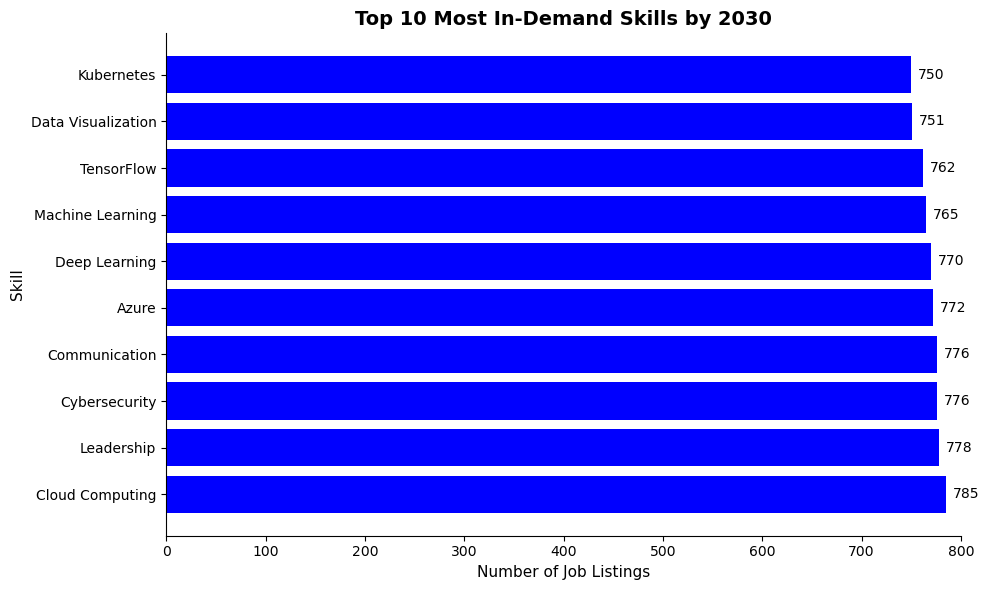

In [180]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(top_skills["Skill"], top_skills["Count"], color="b", edgecolor="none")

ax.bar_label(bars, fmt="%d", padding=5, fontsize=10)

ax.set_title("Top 10 Most In-Demand Skills by 2030", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Job Listings", fontsize=11)
ax.set_ylabel("Skill", fontsize=11)

ax.set_xlim(0, 800)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("visuals/chart3_top_skills.png", dpi=150, bbox_inches="tight")
plt.show()

#### Cloud Computing is the most in-demand skill with 785 mentions, 
followed by Leadership and Communication. The top 10 skills span both 
technical and soft skills — suggesting employers expect workers to 
combine technical expertise with human capabilities by 2030.

In [135]:
hiring_trend = df["Hiring_Trend_2026"].value_counts().reset_index()

hiring_trend

,Hiring_Trend_2026,count
0,Growing,1010
1,Stable,1010
2,Declining,980


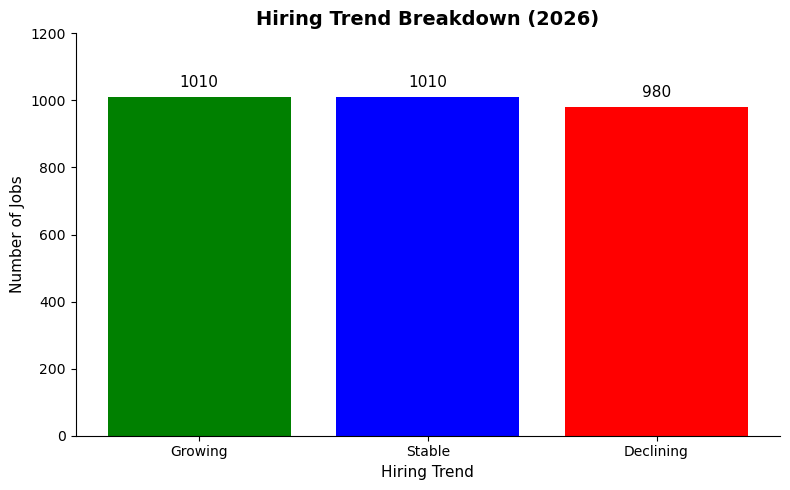

In [181]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(hiring_trend["Hiring_Trend_2026"], hiring_trend["count"], 
              color=["g", "b", "r"], edgecolor="none")

ax.bar_label(bars, fmt="%d", padding=5, fontsize=11)

ax.set_title("Hiring Trend Breakdown (2026)", fontsize=14, fontweight="bold")
ax.set_xlabel("Hiring Trend", fontsize=11)
ax.set_ylabel("Number of Jobs", fontsize=11)

ax.set_ylim(0, 1200)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("visuals/chart4_hiring_trend.png", dpi=150, bbox_inches="tight")
plt.show()

#### Growing and Stable jobs are nearly equal at 1,010 each, while 
Declining jobs stand at 980 — only a 3% difference. This suggests 
AI is not yet causing mass job elimination but rather a gradual 
shift in the nature of work.

In [140]:
jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Employee_ID              3000 non-null   object  
 1   Job_Title                3000 non-null   object  
 2   Industry                 3000 non-null   object  
 3   Country                  3000 non-null   object  
 4   Education_Level          3000 non-null   object  
 5   Years_Experience         3000 non-null   int64   
 6   AI_Replacement_Risk      3000 non-null   float64 
 7   Future_Demand_Score      3000 non-null   float64 
 8   Remote_Work_Possibility  3000 non-null   object  
 9   Average_Salary_USD       3000 non-null   int64   
 10  Required_Skills          3000 non-null   object  
 11  Automation_Level         3000 non-null   object  
 12  Job_Growth_2030          3000 non-null   int64   
 13  Work_Hours_Per_Week      3000 non-null   int64   
 14  Company_

In [146]:
import seaborn as sns

corr_matrix = df[["AI_Replacement_Risk", "Average_Salary_USD", "Years_Experience", 
                   "Job_Growth_2030", "Future_Demand_Score", 
                   "Performance_Score", "Job_Satisfaction"]].corr()

corr_matrix

,AI_Replacement_Risk,Average_Salary_USD,Years_Experience,Job_Growth_2030,Future_Demand_Score,Performance_Score,Job_Satisfaction
AI_Replacement_Risk,1.000000,-0.006714,-0.033668,0.004887,0.007761,-0.012806,0.016181
Average_Salary_USD,-0.006714,1.000000,0.012795,-0.011723,0.005162,-0.009519,0.017736
Years_Experience,-0.033668,0.012795,1.000000,-0.023781,-0.047494,0.023758,0.018071
Job_Growth_2030,0.004887,-0.011723,-0.023781,1.000000,0.054455,-0.011879,0.001757
Future_Demand_Score,0.007761,0.005162,-0.047494,0.054455,1.000000,0.018239,0.012901
Performance_Score,-0.012806,-0.009519,0.023758,-0.011879,0.018239,1.000000,-0.013037
Job_Satisfaction,0.016181,0.017736,0.018071,0.001757,0.012901,-0.013037,1.000000


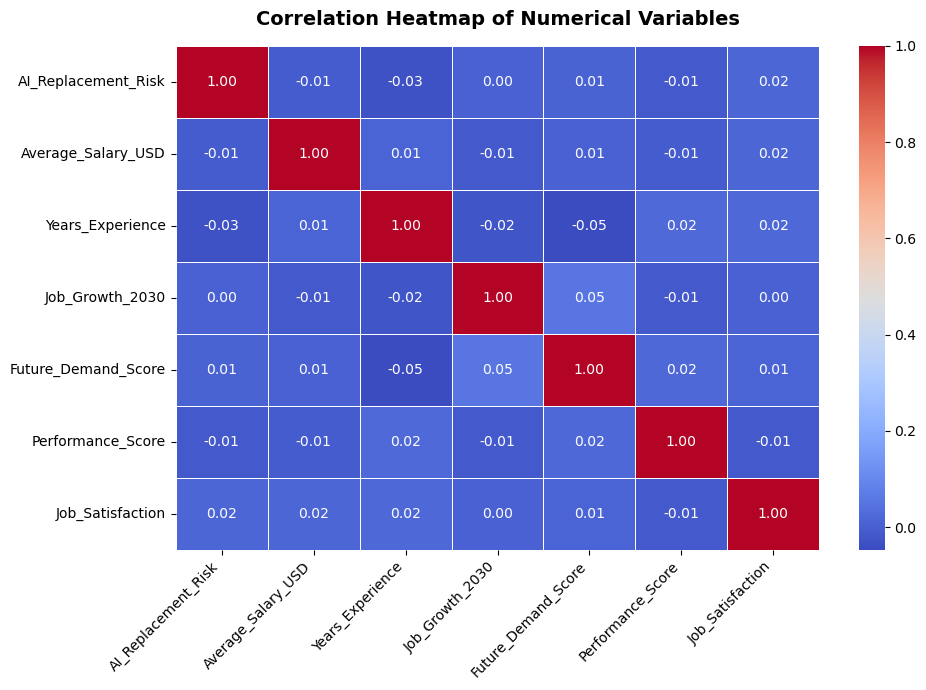

In [183]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
            linewidths=0.5, ax=ax)

ax.set_title("Correlation Heatmap of Numerical Variables", 
             fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("visuals/chart5_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

#### All correlation values are close to 0, indicating no strong linear relationship exists between any of the numerical variables. This suggests AI replacement risk is not significantly driven by salary, experience, or job satisfaction alone — other factors such as job type and automation level likely play a bigger role.



In [154]:
country_risk = (df.groupby("Country")["AI_Replacement_Risk"]
                  .mean()
                  .sort_values(ascending=True).reset_index())

country_risk

,Country,AI_Replacement_Risk
0,Singapore,0.484944
1,India,0.495520
2,UK,0.495570
3,USA,0.497390
4,Australia,0.500769
5,Canada,0.501684
6,Germany,0.505346
7,UAE,0.506455
8,Japan,0.511773
9,Pakistan,0.526367


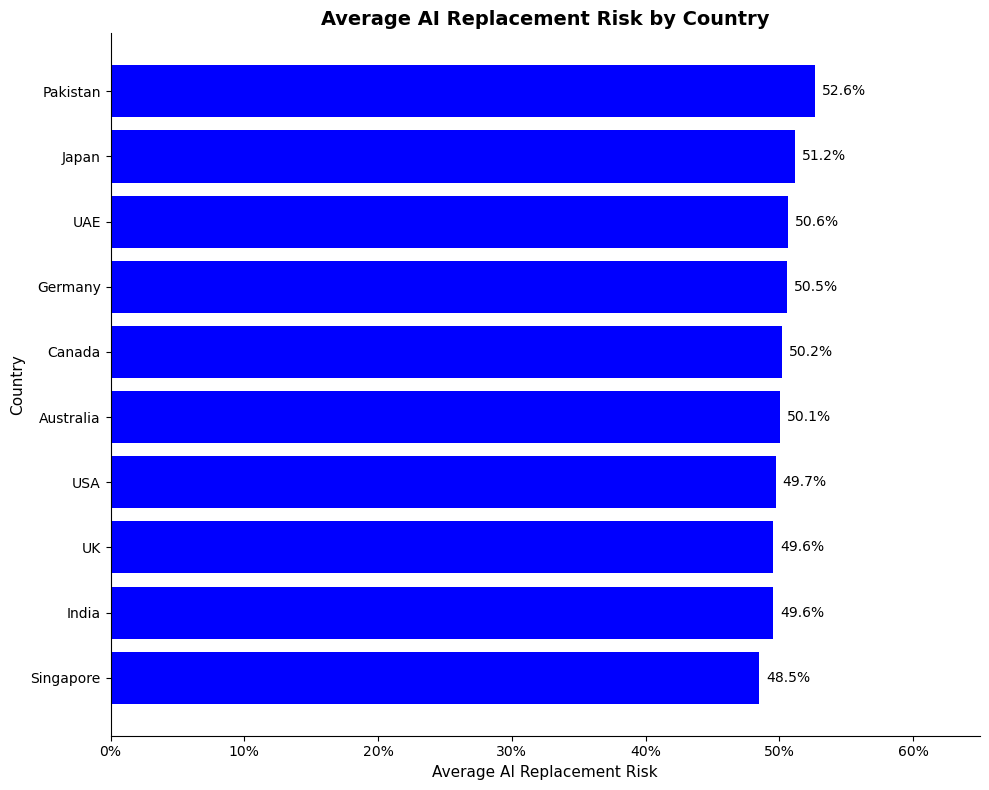

In [184]:
fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(country_risk["Country"], country_risk["AI_Replacement_Risk"], 
               color="b")

ax.bar_label(bars, fmt=lambda x: f"{x * 100:.1f}%", padding=5, fontsize=10)

ax.set_title("Average AI Replacement Risk by Country", fontsize=14, fontweight="bold")
ax.set_xlabel("Average AI Replacement Risk", fontsize=11)
ax.set_ylabel("Country", fontsize=11)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x * 100:.0f}%"))
ax.set_xlim(0, 0.65)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("visuals/chart6_country_risk.png", dpi=150, bbox_inches="tight")
plt.show()

#### Pakistan has the highest AI replacement risk at 52.6% while Singapore is the most insulated at 48.5%. Similar to the industry analysis, the spread across all 10 countries is narrow at just 4.1% — suggesting AI disruption is a global phenomenon not concentrated in any specific region.

In [156]:
job_growth = (df.groupby("Industry")["Job_Growth_2030"]
                .mean()
                .sort_values(ascending=True)
                 .reset_index())

job_growth

,Industry,Job_Growth_2030
0,Transportation,15.870307
1,Healthcare,15.875458
2,Manufacturing,16.392739
3,Retail,16.519298
4,Energy,17.092537
5,Media,17.644599
6,Education,17.880000
7,Technology,18.013746
8,Government,18.275542
9,Finance,18.570968


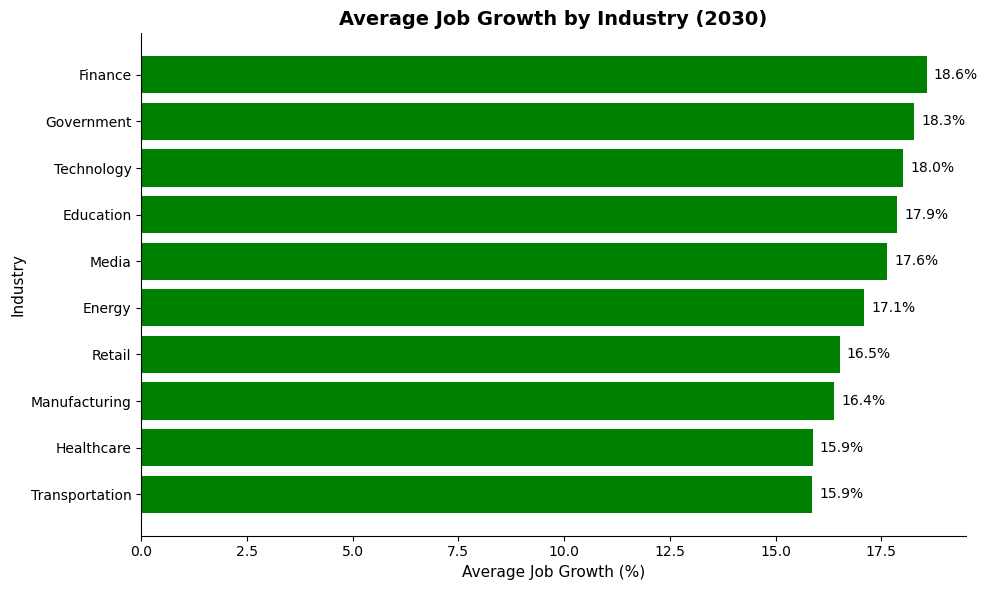

In [185]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(job_growth["Industry"], job_growth["Job_Growth_2030"], 
               color="g")

ax.bar_label(bars, fmt="%.1f%%", padding=5, fontsize=10)

ax.set_title("Average Job Growth by Industry (2030)", fontsize=14, fontweight="bold")
ax.set_xlabel("Average Job Growth (%)", fontsize=11)
ax.set_ylabel("Industry", fontsize=11)


ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("visuals/chart7_job_growth.png", dpi=150, bbox_inches="tight")
plt.show()

#### Finance leads projected job growth at 18.6% by 2030, while Transportation and Healthcare show the lowest growth at 15.9%. Interestingly Finance also had the highest AI replacement risk — suggesting it will simultaneously see the most disruption and the most new job creation.

In [163]:
upskilling = (df.groupby(["Risk_Tier", "Upskilling_Needed"])
                .size()
                .reset_index(name="Count"))

upskilling

,Risk_Tier,Upskilling_Needed,Count
0,High Risk,No,440
1,High Risk,Yes,415
2,Low Risk,No,578
3,Low Risk,Yes,592
4,Medium Risk,No,493
5,Medium Risk,Yes,482


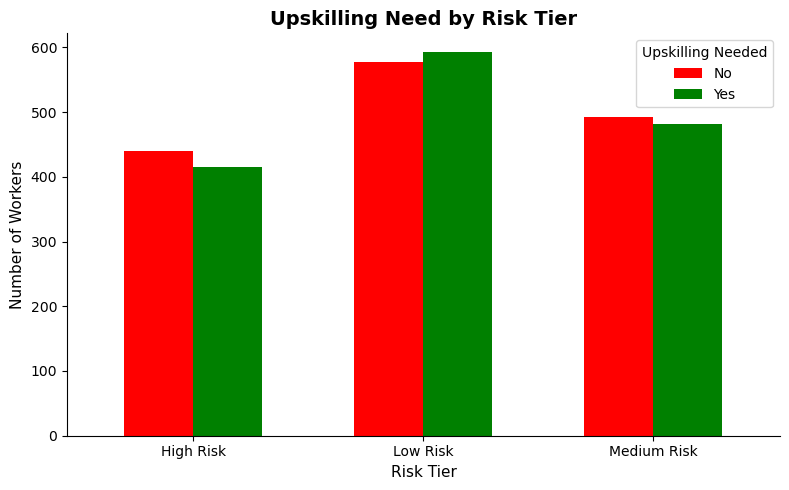

In [186]:
upskilling_pivot = upskilling.pivot(index="Risk_Tier", 
                                     columns="Upskilling_Needed", 
                                     values="Count")

fig, ax = plt.subplots(figsize=(8, 5))

upskilling_pivot.plot(kind="bar", ax=ax, color=["r", "g"], 
                      edgecolor="none", width=0.6)


ax.set_title("Upskilling Need by Risk Tier", fontsize=14, fontweight="bold")
ax.set_xlabel("Risk Tier", fontsize=11)
ax.set_ylabel("Number of Workers", fontsize=11)
ax.legend(title="Upskilling Needed", fontsize=10)

plt.xticks(rotation=0)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("visuals/chart8_upskilling.png", dpi=150, bbox_inches="tight")
plt.show()

#### *Upskilling need is fairly evenly split across all risk tiers — suggesting that the need to learn new skills is not exclusive to high risk workers. Notably Low Risk workers show the highest upskilling need at 592, indicating that even workers in safe roles recognise the importance of continuous learning to stay relevant by 2030*.

## Summary of Key Findings

| Finding | Value |
|---------|-------|
| Highest risk industry | Finance (53.0%) |
| Lowest risk industry | Healthcare (47.5%) |
| Highest risk country | Pakistan (52.6%) |
| Lowest risk country | Singapore (48.5%) |
| Most in-demand skill | Cloud Computing (785) |
| Jobs growing | 1,010 (33.67%) |
| Jobs stable | 1,010 (33.67%) |
| Jobs declining | 980 (32.67%) |
| Highest job growth industry | Finance (18.6%) |

AI disruption risk is broadly distributed across industries, countries, 
and job titles — suggesting the impact of AI on employment by 2030 will 
be a global, cross-sector shift rather than an isolated phenomenon.